# Customer Segmentation Using K-Means Clustering

# Introduction

Customer segmentation is a data analytics technique used to divide customers into groups based on similar characteristics. This project uses the K-Means Clustering algorithm to group customers according to their Annual Income and Spending Score.

The generated customer segments can help businesses understand customer behavior, improve marketing strategies, and make better business decisions.

# 1.Import Library

In [36]:
# ==========================================
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display plots inside notebook
%matplotlib inline

# 2.Data Overview

## 2.1 Load dataset

In [7]:
# ==========================================
# Step 2: Load Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers (2).csv


## 2.2 First five rows

## 2.3 Column description

In [35]:
# Display the first five rows to understand the dataset structure
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## 2.4 Datatype of each column

In [8]:
# Display the data type of each column
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


## 2.5 Shape of data

In [10]:
# Check the number of rows and columns in the dataset
df.shape

(200, 5)

## 2.6 Information of each column

In [11]:
# Get basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
# View statistical summary of the numerical columns
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# 3.Data Inspection

## 3.1 Check missing value

In [13]:
# Check if there are any missing values in the dataset
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## 3.2 Check duplicate value

In [14]:
# Count the number of duplicate records
df.duplicated().sum()

np.int64(0)

# 4.Exploratory Data Analysis (EDA)

## 4.1 Gender Distribution

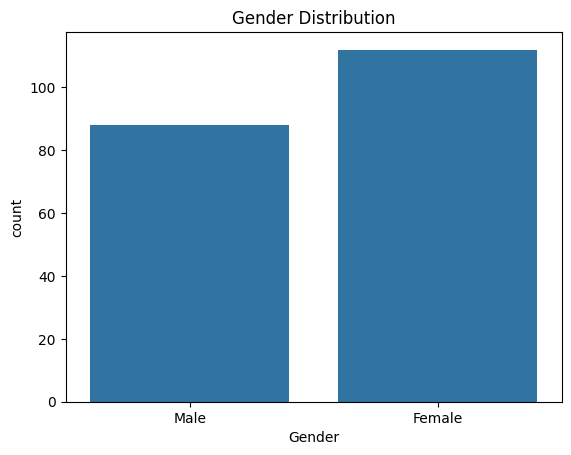

In [17]:
# Display the number of male and female customers
sns.countplot(data=df,x="Gender")
plt.title("Gender Distribution")
plt.show()

- Female customers are slightly more than male customers.

## 4.2 Age Distribution

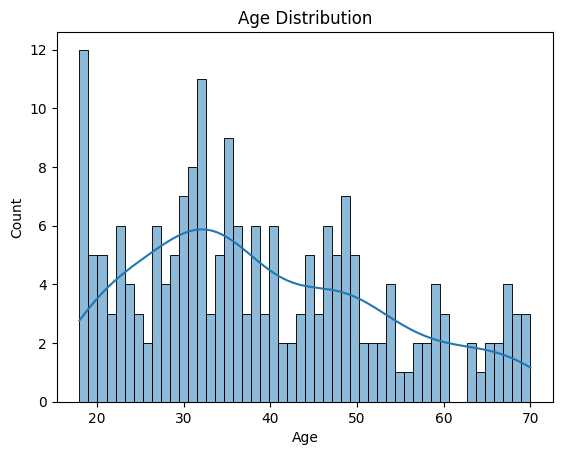

In [18]:
# Show how customer ages are distributed
sns.histplot(df["Age"],bins=50,kde=True)
plt.title("Age Distribution")
plt.show()

- Most customers belong to the 20–35 years age group.

## 4.3 Income Distribution

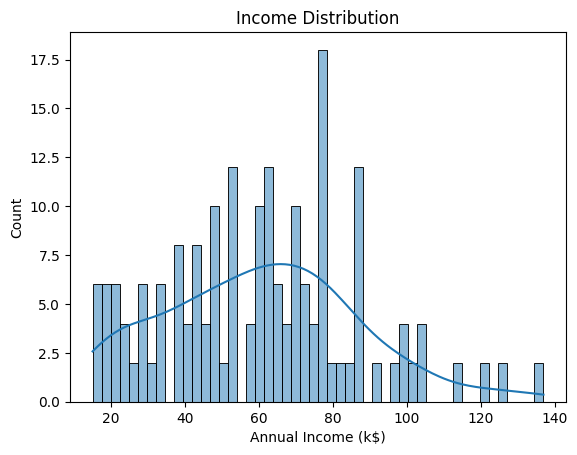

In [19]:
# Display the distribution of customers' annual income
sns.histplot(df["Annual Income (k$)"],bins=50,kde=True)
plt.title("Income Distribution")
plt.show()

- Most customers have a medium annual income,while fewer customers fall into very low or very high income groups.

## 4.4 Spending Score Distribution

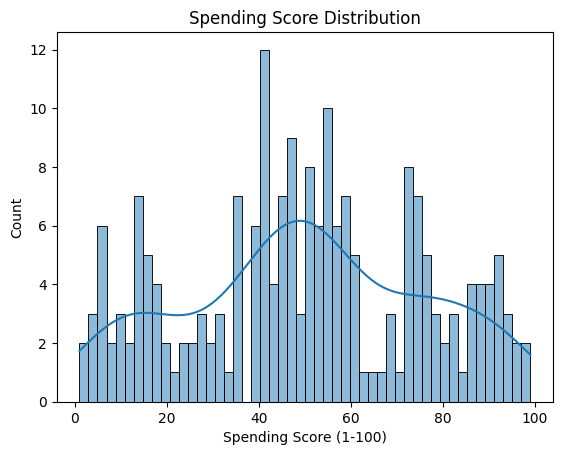

In [20]:
# Show the distribution of customer spending scores
sns.histplot(df["Spending Score (1-100)"],bins=50,kde=True)
plt.title("Spending Score Distribution")
plt.show()

- Spending scores are distributed across the entire range.

## 4.5 Age vs Annual Income

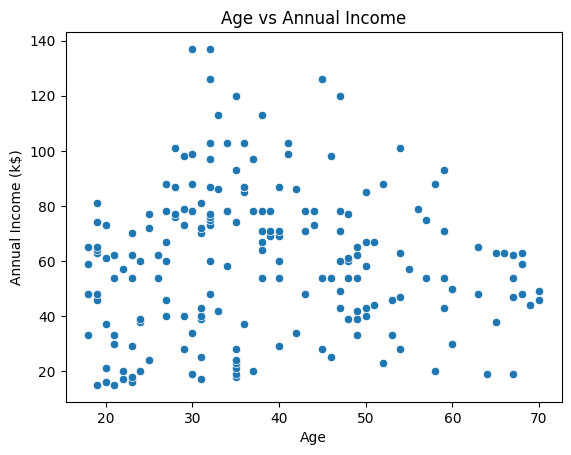

In [21]:
# Compare customer age with annual income
sns.scatterplot(data=df,x="Age",y="Annual Income (k$)")
plt.title("Age vs Annual Income")
plt.show()

- There is no strong relationship between age and annual income.

## 4.6 Annual Income vs Spending Score

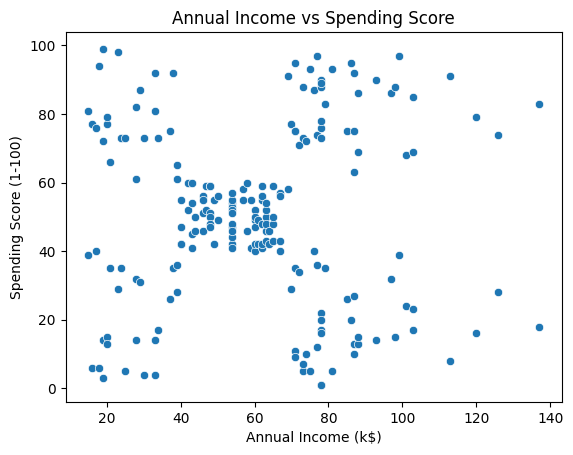

In [22]:
# Compare annual income with spending score
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

- Customers are divided into different groups based on Annual Income and Spending Score.

## 4.7 Correlation heatmap

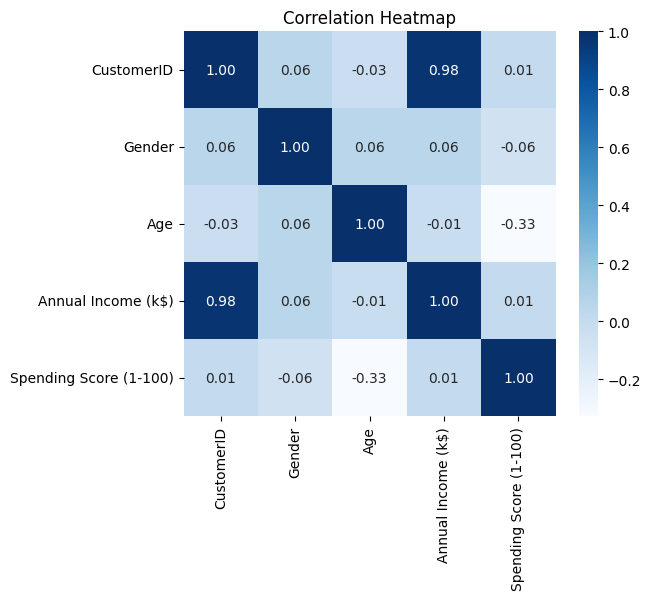

In [37]:
# Display the correlation between numerical columns
plt.figure(figsize=(6,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 5.Data Preprocessing

## 5.1 Encode the gender column

In [24]:
# Convert Gender into numbers for easier processing
df["Gender"] = df["Gender"].map({
    "Male":1,
    "Female":0
})

# 6.Feature Selection

In [38]:
# Select the features required for customer segmentation
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [39]:
# Display the x values
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


# 7.Elbow Method

In [27]:
# Create an empty list to store WCSS values
wcss = []
for i in range(1,11):
    k_means = KMeans(n_clusters=i)
    k_means.fit(x)
    wcss.append(k_means.inertia_)

In [28]:
# Display the WCSS values
wcss

[269981.28000000014,
 181363.59595959607,
 106348.37306211119,
 99154.45568976483,
 44448.45544793369,
 37233.81451071002,
 31615.312520723954,
 25043.890043290034,
 22816.67914205155,
 21073.532235077575]

Elbow Method = It is a technique which used to determine the optimal number of cluster in K-means clustering.

## 7.1 Elbow method graph

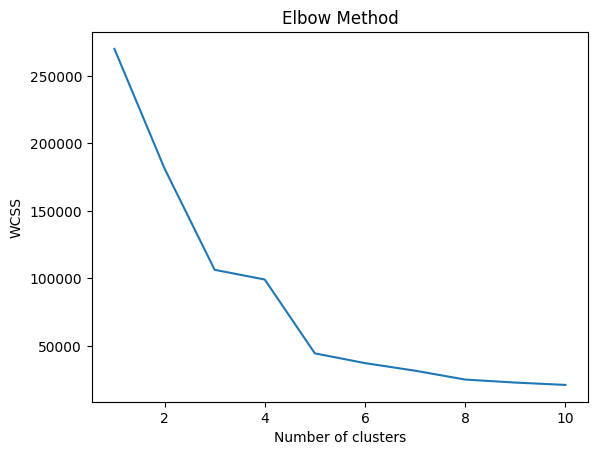

In [29]:
# Plot the Elbow Method graph to find the optimal number of clusters
plt.plot(range(1,11),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# 8.Train K-Means

In [30]:
# Train the K-Means model with 5 clusters
k_means = KMeans(n_clusters=5,random_state=42)
# Predict the cluster for each customer
y_pred = k_means.fit_predict(x)

In [31]:
# Display the cluster assigned to each customer
y_pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

# 9.Visualize Clusters

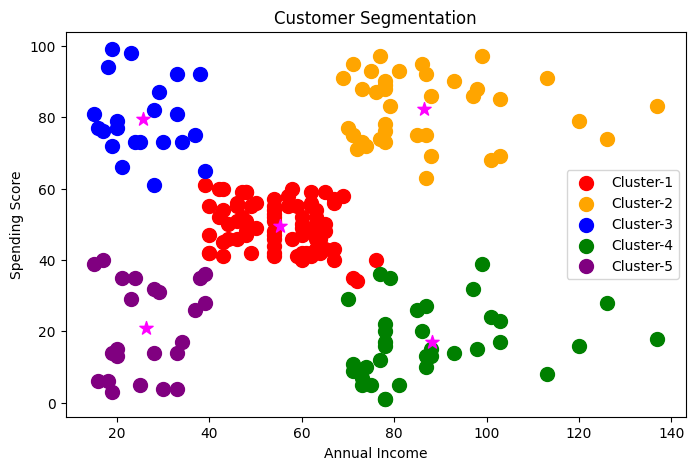

In [41]:
# Visualize the customer segments using different colors
plt.figure(figsize=(8,5))

colors = ["red", "orange", "blue", "green", "purple"]
for i in range(5):
    plt.scatter(
        x.iloc[y_pred == i,0],
        x.iloc[y_pred == i,1],
        s=100,
        c=colors[i],
        label=f"Cluster-{i+1}"
    )

# Mark the center of each cluster
plt.scatter(
    k_means.cluster_centers_[:,0],
    k_means.cluster_centers_[:,1],
    s=100,
    marker="*",
    c="magenta"
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()

plt.show()

## Customer Segments

- **Cluster 1:** Average customers with medium income and medium spending.

- **Cluster 2:** Premium customers with high income and high spending.

- **Cluster 3:** Customers with low income but high spending.

- **Cluster 4:** Customers with high income but low spending.

- **Cluster 5:** Budget customers with low income and low spending.

# 10.Conclusion

This project successfully applied the K-Means clustering algorithm to segment customers based on Annual Income and Spending Score.

The project involved data loading, preprocessing, exploratory data analysis, visualization, and machine learning implementation.

The generated customer segments can help businesses understand customer behavior, improve customer targeting, and support better business decisions.



In [34]:
# ==========================================
# Predict a New Customer
# ==========================================

new_customer = pd.DataFrame({
    "Annual Income (k$)": [80],
    "Spending Score (1-100)": [20]
})

prediction = k_means.predict(new_customer)

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 3
